In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import re
import cmcrameri.cm as cm
import pandas as pd
import matplotlib.lines as mlines
import matplotlib.animation as animation


In [170]:
def read_h5var(hf: h5py.File, var_name: str, time_idx: int) -> np.ndarray:
    """
    Read a variable from an already-open HDF5 file.

    Args:
        hf:        An open h5py.File object.
        var_name:  The variable name to read (e.g. 'temperature').
        time_idx:  Timestep index. Negative values index from the end,
                   like Python list indexing.

    Returns:
        The variable array, flipped along axis 0.

    Raises:
        TypeError:  If time_idx is not an integer type.
        KeyError:   If var_name has no timesteps in the file.
        IndexError: If time_idx is out of range.
    """
    if not isinstance(time_idx, (int, np.integer)):
        raise TypeError(f"time_idx must be an integer, got {type(time_idx).__name__}")

    # Resolve the actual timestep key, handling negative indices
    if time_idx < 0:
        var_times = sorted(
            int(key.split('.')[1])
            for key in hf
            if key.split('.')[0] == var_name
        )
        if not var_times:
            raise KeyError(f"No timesteps found for variable '{var_name}'")
        if not -len(var_times) <= time_idx < len(var_times):
            raise IndexError(f"time_idx {time_idx} out of range for {len(var_times)} timesteps")
        time_idx = var_times[time_idx]
        print(time_idx)

    key = f'{var_name}.{time_idx}'
    if key not in hf:
        raise KeyError(f"Key '{key}' not found in HDF5 file")

    return np.flip(hf[key][()], axis=0)

100


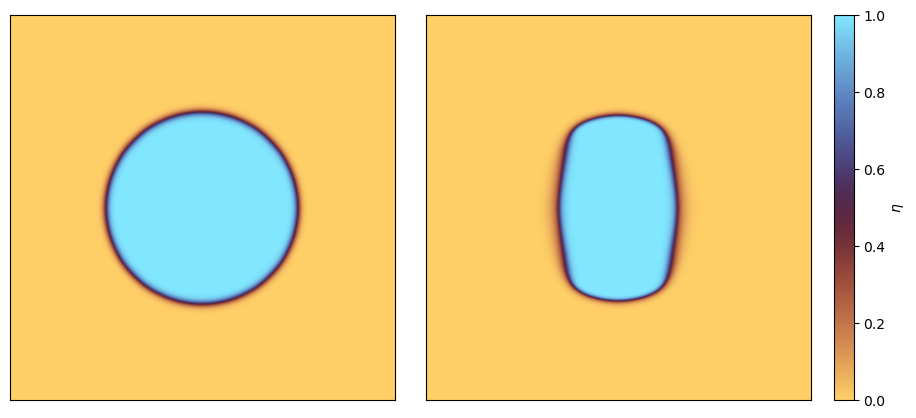

In [225]:
filename = 'parsed_aniso.h5'

with h5py.File(filename, 'r') as hf:
    var_first = read_h5var(hf, 'eta', 0)
    var_last  = read_h5var(hf, 'eta', -1)

vmin = min(var_first.min(), var_last.min())
vmax = max(var_first.max(), var_last.max())

fig = plt.figure(figsize=(11, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.05)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1, sharey=ax1)
cax = fig.add_subplot(gs[2])

ax1.imshow(var_first, cmap=cm.managua, vmin=vmin, vmax=vmax)
im = ax2.imshow(var_last,  cmap=cm.managua, vmin=vmin, vmax=vmax)

for ax in (ax1, ax2):
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

fig.colorbar(im, cax=cax,label=r'$\eta$')
plt.show()

100
100


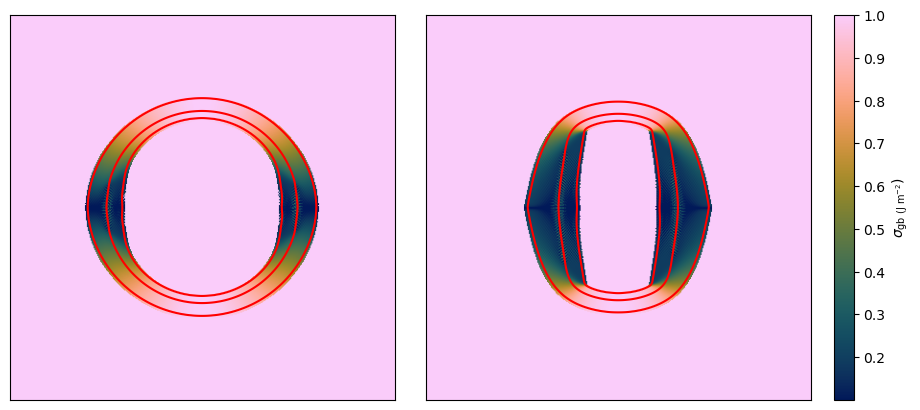

In [226]:
ts_max = -1
with h5py.File(filename, 'r') as hf:
    var_first = read_h5var(hf, 'sigma', 1)
    var_last  = read_h5var(hf, 'sigma', ts_max)
    var_first_ctr = read_h5var(hf, 'eta', 1)
    var_last_ctr = read_h5var(hf, 'eta', ts_max)

vmin = min(var_first.min(), var_last.min())
vmax = max(var_first.max(), var_last.max())

extent = [0, 40, 0, 40]

fig = plt.figure(figsize=(11, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.05)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1, sharey=ax1)
cax = fig.add_subplot(gs[2])

ax1.imshow(var_first, cmap=cm.batlow, vmin=vmin, vmax=vmax,extent=extent)
im = ax2.imshow(var_last,  cmap=cm.batlow, vmin=vmin, vmax=vmax,extent=extent)
fig.colorbar(im, cax=cax,label=r'$\sigma_{\mathrm{gb}\ (\mathrm{J\ m^{-2}}} )$')

ax1.contour(var_first_ctr, levels=[0.001,0.5,0.999], colors='r', extent=extent)
ax2.contour(var_last_ctr, levels=[0.001,0.5,0.999], colors='r', extent=extent)

for ax in (ax1, ax2):
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)


plt.show()

(0.0, 15.0)

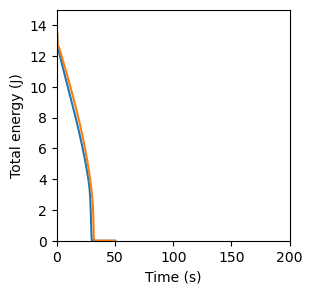

In [228]:
df_torque = pd.read_csv('with_torque.csv')
df_no_torque = pd.read_csv('without_torque.csv')

fig = plt.figure(figsize=(3,3))

for df in [df_torque,df_no_torque]:
    time = df['time'].to_numpy()[1:]
    gb_energy = df['total_gb_energy'][1:]
    plt.plot(time,gb_energy)

plt.ylabel('Total energy (J)')
plt.xlabel('Time (s)')

plt.xlim(0,200)
plt.ylim(0,15)

In [ ]:
filename = 'with_torque.h5'
with h5py.File(filename, 'r') as hf:
    var_torque = read_h5var(hf, 'eta', 25)

filename = 'without_torque.h5'
with h5py.File(filename, 'r') as hf:
    var_no_torque = read_h5var(hf, 'eta', 25)

extent = [0, 40, 0, 40]

fig, ax = plt.subplots(figsize=(6, 6))
P1 = ax.contour(var_torque,    levels=[0.5], colors='royalblue', extent=extent)
P2 = ax.contour(var_no_torque, levels=[0.5], colors='tomato', extent=extent)

ax.set_aspect('equal')
# ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Legend workaround — contour collections aren't directly legend-able
legend_elements = [
    mlines.Line2D([0], [0], color='royalblue', label='With torque'),
    mlines.Line2D([0], [0], color='tomato',    label='Without torque'),
]
ax.legend(handles=legend_elements)

plt.show()

KeyError: "Key 'eta.101' not found in HDF5 file"

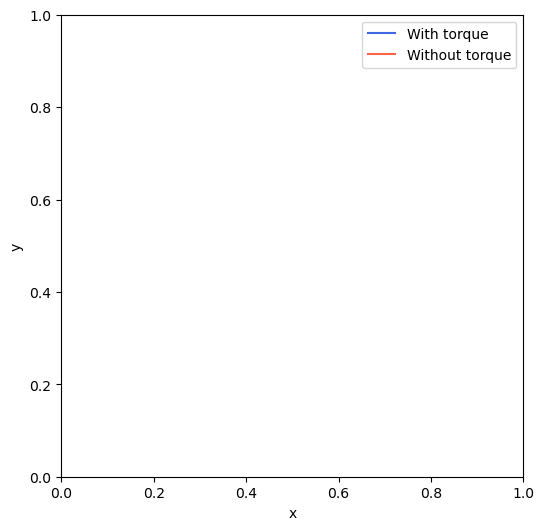

In [ ]:
import matplotlib.animation as animation

extent = [0, 40, 0, 40]
n_steps = 101  # t=0 through t=25

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')

legend_elements = [
    mlines.Line2D([0], [0], color='royalblue', label='With torque'),
    mlines.Line2D([0], [0], color='tomato',    label='Without torque'),
]
ax.legend(handles=legend_elements)

# Pre-load all timesteps once
with h5py.File('with_torque.h5', 'r') as hf:
    frames_torque    = [read_h5var(hf, 'eta', t) for t in range(n_steps)]

with h5py.File('without_torque.h5', 'r') as hf:
    frames_no_torque = [read_h5var(hf, 'eta', t) for t in range(n_steps)]

def animate(t):
    ax.cla()
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Timestep {t}')
    ax.contour(frames_torque[t],    levels=[0.5], colors='royalblue', extent=extent)
    ax.contour(frames_no_torque[t], levels=[0.5], colors='tomato',    extent=extent)
    ax.legend(handles=legend_elements)

anim = animation.FuncAnimation(fig, animate, frames=n_steps, interval=100)
anim.save('eta_evolution.gif', writer='pillow', dpi=120)
plt.show()